**Optimasi Performa Iklan Digital untuk Meningkatkan Profit Bisnis - Digital Marketing Performance Optimization**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/ghifarryalnaffriza/Python_Ads_performance_Analyst/refs/heads/main/Data%20Ads%20-%20Kompetisi%20Data%20Analyts%20by%20inSight%20Data%20Batch%2001%20(3).csv"
df = pd.read_csv(url)

In [ ]:
df.head()

,created_date,account_name,campaign_objective,impressions,reach,clicks,link_clicks,content_views,add_to_cart,purchase,purchase_value,amount_spent
0,2023-01-01,Client A - Fashion,Traffic,915434.0,81436.0,92554.0,15544.0,0.0,0.0,0.0,0.0,2357742.0
1,2023-01-01,Client A - Fashion,Sales,103328.0,89200.0,22100.0,38038.0,1199.0,817.0,824.0,3353702.0,3578529.0
2,2023-01-01,Client B - Beauty,Traffic,336015.0,141082.0,26321.0,46107.0,0.0,0.0,0.0,0.0,1482711.0
3,2023-01-01,Client B - Beauty,Sales,864410.0,400596.0,10719.0,29397.0,3395.0,960.0,591.0,3470984.0,4335272.0
4,2023-01-01,Client C - Fashion,Traffic,916254.0,319415.0,32995.0,37496.0,0.0,0.0,0.0,0.0,1897353.0


In [ ]:
df.shape

(4380, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   created_date        4380 non-null   object 
 1   account_name        4380 non-null   object 
 2   campaign_objective  4380 non-null   object 
 3   impressions         4380 non-null   float64
 4   reach               4380 non-null   float64
 5   clicks              4380 non-null   float64
 6   link_clicks         4380 non-null   float64
 7   content_views       4380 non-null   float64
 8   add_to_cart         4380 non-null   float64
 9   purchase            4380 non-null   float64
 10  purchase_value      4380 non-null   float64
 11  amount_spent        4380 non-null   float64
dtypes: float64(9), object(3)
memory usage: 410.8+ KB


In [ ]:
df.describe()

,impressions,reach,clicks,link_clicks,content_views,add_to_cart,purchase,purchase_value,amount_spent
count,4.380000e+03,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4.380000e+03,4.380000e+03
mean,6.509784e+05,319465.963721,64658.303105,32284.340525,3270.216758,329.622032,299.895434,2.385893e+06,2.957227e+06
std,3.561788e+05,177837.971292,35658.804018,17818.611700,4149.902583,416.383348,401.934926,3.200339e+06,1.858174e+06
min,1.003580e+05,50134.000000,10029.000000,5008.000000,0.000000,0.000000,0.000000,0.000000e+00,1.014850e+05
25%,3.682400e+05,178756.300000,36632.250000,17758.200000,0.000000,0.000000,0.000000,0.000000e+00,1.474532e+06
50%,6.193560e+05,305107.500000,61225.000000,30892.500000,505.000000,50.000000,5.000000,5.176000e+04,2.856742e+06
75%,8.774980e+05,428148.125000,86084.450000,43292.750000,6296.150000,630.000000,560.250000,4.531508e+06,4.153663e+06
max,1.998018e+06,998320.000000,199252.000000,99554.000000,19964.000000,1992.000000,1980.000000,1.590125e+07,9.970642e+06


In [ ]:
# cek nilai kosong
df.isnull().sum()

,0
created_date,0
account_name,0
campaign_objective,0
impressions,0
reach,0
clicks,0
link_clicks,0
content_views,0
add_to_cart,0
purchase,0


In [ ]:
# cek duplikat
print("Baris duplikat:", df.duplicated().sum())

Baris duplikat: 0


In [ ]:
# rentang tanggal
print("Periode:", df['created_date'].min(), "sampai", df['created_date'].max())

Periode: 2023-01-01 sampai 2023-12-31


## DATA PREPARATION

In [ ]:
# ubah tanggal jadi format datetime
df['created_date'] = pd.to_datetime(df['created_date'])
df['month'] = df['created_date'].dt.month

In [ ]:
# pisahkan nama klien dan industri
df['client']   = df['account_name'].str.split(' - ').str[0]
df['industry'] = df['account_name'].str.split(' - ').str[1]

In [ ]:
# hitung metrik per baris
df['CTR']      = df['clicks'] / df['impressions']
df['link_CTR'] = df['link_clicks'] / df['impressions']
df['ROAS']     = df['purchase_value'] / df['amount_spent']

In [ ]:
# pisahkan data Sales dan Traffic
sales   = df[df['campaign_objective'] == 'Sales']
traffic = df[df['campaign_objective'] == 'Traffic']

In [ ]:
df.head()

,created_date,account_name,campaign_objective,impressions,reach,clicks,link_clicks,content_views,add_to_cart,purchase,purchase_value,amount_spent,month,client,industry,CTR,link_CTR,ROAS
0,2023-01-01,Client A - Fashion,Traffic,915434.0,81436.0,92554.0,15544.0,0.0,0.0,0.0,0.0,2357742.0,1,Client A,Fashion,0.101104,0.016980,0.000000
1,2023-01-01,Client A - Fashion,Sales,103328.0,89200.0,22100.0,38038.0,1199.0,817.0,824.0,3353702.0,3578529.0,1,Client A,Fashion,0.213882,0.368129,0.937173
2,2023-01-01,Client B - Beauty,Traffic,336015.0,141082.0,26321.0,46107.0,0.0,0.0,0.0,0.0,1482711.0,1,Client B,Beauty,0.078333,0.137217,0.000000
3,2023-01-01,Client B - Beauty,Sales,864410.0,400596.0,10719.0,29397.0,3395.0,960.0,591.0,3470984.0,4335272.0,1,Client B,Beauty,0.012400,0.034008,0.800638
4,2023-01-01,Client C - Fashion,Traffic,916254.0,319415.0,32995.0,37496.0,0.0,0.0,0.0,0.0,1897353.0,1,Client C,Fashion,0.036011,0.040923,0.000000


## EXECUTIVE SUMMARY

In [ ]:
total_spend   = df['amount_spent'].sum()
total_revenue = df['purchase_value'].sum()
print("Total Spend         : Rp", round(total_spend))
print("Total Purchase Value: Rp", round(total_revenue))
print("Profit proxy        : Rp", round(total_revenue - total_spend))
print("CTR Overall         :", round(df['clicks'].sum()/df['impressions'].sum()*100, 2), "%")
print("ROAS Overall        :", round(total_revenue/total_spend, 2), "x")

Total Spend         : Rp 12952655222
Total Purchase Value: Rp 10450212835
Profit proxy        : Rp -2502442386
CTR Overall         : 9.93 %
ROAS Overall        : 0.81 x


## A. PERFORMANCE METRICS

**A1 & A2 - CTR keseluruhan & per objective**

In [ ]:
# CTR keseluruhan
ctr_total = df['clicks'].sum() / df['impressions'].sum()
print("CTR keseluruhan:", round(ctr_total * 100, 2), "%")

CTR keseluruhan: 9.93 %


In [ ]:
# CTR per objective
per_obj = df.groupby('campaign_objective').agg(
    impressions=('impressions', 'sum'),
    clicks=('clicks', 'sum'),
    revenue=('purchase_value', 'sum'),
    spend=('amount_spent', 'sum'),
)
per_obj['CTR']  = per_obj['clicks'] / per_obj['impressions']
per_obj['ROAS'] = per_obj['revenue'] / per_obj['spend']
print(per_obj[['CTR', 'ROAS']])

                         CTR      ROAS
campaign_objective                    
Sales               0.098803  1.618389
Traffic             0.099846  0.000000


**A3 - Total omzet (purchase value)**

In [ ]:
total_omzet = df['purchase_value'].sum()
print("Total omzet: Rp", round(total_omzet))

Total omzet: Rp 10450212835


**A4 - ROAS keseluruhan**

In [ ]:
roas_total = df['purchase_value'].sum() / df['amount_spent'].sum()
print("ROAS keseluruhan (blended):", round(roas_total, 2))

ROAS keseluruhan (blended): 0.81


In [ ]:
# ROAS khusus Sales
roas_sales = sales['purchase_value'].sum() / sales['amount_spent'].sum()
print("ROAS Sales:", round(roas_sales, 2))

ROAS Sales: 1.62


In [ ]:
# porsi budget Traffic
porsi_traffic = traffic['amount_spent'].sum() / df['amount_spent'].sum()
print("Budget Traffic:", round(porsi_traffic * 100), "% dari total (revenue = 0)")

Budget Traffic: 50 % dari total (revenue = 0)


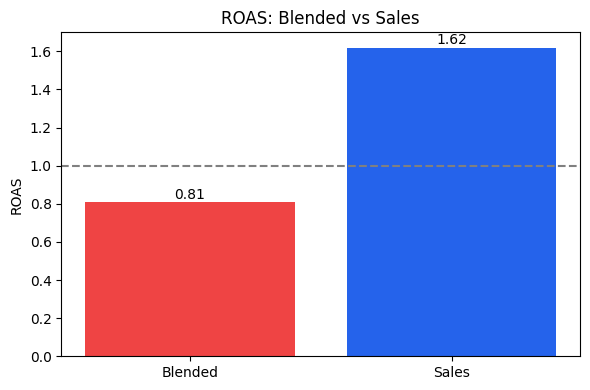

In [ ]:
# Grafik: ROAS blended vs Sales
plt.figure(figsize=(6, 4))
plt.bar(['Blended', 'Sales'], [roas_total, roas_sales], color=['#ef4444', '#2563eb'])
plt.axhline(1, linestyle='--', color='gray')   # garis break-even
plt.title('ROAS: Blended vs Sales')
plt.ylabel('ROAS')
for i, v in enumerate([roas_total, roas_sales]):
    plt.text(i, v + 0.02, round(v, 2), ha='center')
plt.tight_layout()
plt.show()

## B. TREND & TIME SERIES

**B1 & B2 - Tren omzet per bulan**

In [ ]:
# omzet & ROAS per bulan (Sales)
per_bulan = sales.groupby('month').agg(
    omzet=('purchase_value', 'sum'),
    spend=('amount_spent', 'sum'),
)
per_bulan['ROAS'] = per_bulan['omzet'] / per_bulan['spend']
print(per_bulan)

print("Bulan omzet tertinggi:", per_bulan['omzet'].idxmax())
print("Bulan omzet terendah:", per_bulan['omzet'].idxmin())

              omzet        spend      ROAS
month                                     
1      7.780761e+08  478066998.0  1.627546
2      6.951760e+08  422866821.0  1.643960
3      7.125986e+08  493284581.0  1.444599
4      1.494403e+09  946081360.0  1.579572
5      7.651272e+08  486804248.0  1.571735
6      7.385859e+08  468666462.0  1.575931
7      7.639872e+08  453220245.0  1.685686
8      7.572559e+08  468817379.0  1.615247
9      7.336739e+08  440180315.0  1.666758
10     9.347719e+08  557952435.6  1.675361
11     1.021654e+09  572303160.8  1.785162
12     1.054903e+09  668927185.5  1.577007
Bulan omzet tertinggi: 4
Bulan omzet terendah: 2


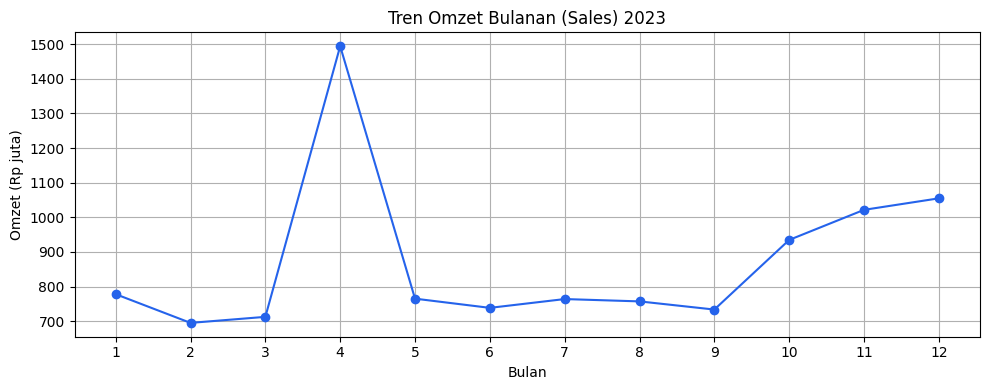

In [ ]:
# Grafik: tren omzet bulanan
plt.figure(figsize=(10, 4))
plt.plot(per_bulan.index, per_bulan['omzet'] / 1e6, marker='o', color='#2563eb')
plt.title('Tren Omzet Bulanan (Sales) 2023')
plt.xlabel('Bulan')
plt.ylabel('Omzet (Rp juta)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

**B3 - Pola musiman: weekday vs weekend**

In [ ]:
# tandai akhir pekan (Sabtu=5, Minggu=6)
sales_copy = sales.copy()
sales_copy['weekday'] = sales_copy['created_date'].dt.weekday
# Sabtu (5) & Minggu (6) = Weekend, sisanya Weekday
sales_copy['tipe_hari'] = 'Weekday'
sales_copy.loc[sales_copy['weekday'] >= 5, 'tipe_hari'] = 'Weekend'

per_hari = sales_copy.groupby('tipe_hari').agg(
    omzet=('purchase_value', 'sum'),
    spend=('amount_spent', 'sum'),
)
per_hari['ROAS'] = per_hari['omzet'] / per_hari['spend']
print(per_hari[['ROAS']])

               ROAS
tipe_hari          
Weekday    1.632559
Weekend    1.584891


## C. INDUSTRY & ACCOUNT ANALYSIS

**C1 - Rata-rata omzet per industri**

In [ ]:
rata_industri = sales.groupby('industry')['purchase_value'].mean().sort_values(ascending=False)
print("Rata-rata omzet harian per industri:")
print(rata_industri)

Rata-rata omzet harian per industri:
industry
Beauty     4.797886e+06
Fashion    4.779905e+06
FMCG       4.737569e+06
Name: purchase_value, dtype: float64


**C2 - Akun paling efektif (revenue tertinggi)**

In [ ]:
# efisiensi per akun: ROAS & CPA
per_akun = sales.groupby('client').agg(
    revenue=('purchase_value', 'sum'),
    spend=('amount_spent', 'sum'),
    purchase=('purchase', 'sum'),
)
per_akun['ROAS'] = per_akun['revenue'] / per_akun['spend']
per_akun['CPA']  = per_akun['spend'] / per_akun['purchase']
print(per_akun[['revenue', 'ROAS', 'CPA']].sort_values('revenue', ascending=False))

               revenue      ROAS          CPA
client                                       
Client C  1.779702e+09  1.671700  4768.422244
Client D  1.762483e+09  1.616330  5059.983177
Client B  1.739974e+09  1.671834  4693.686524
Client E  1.739546e+09  1.634887  4619.237568
Client F  1.718880e+09  1.552612  5329.469272
Client A  1.709628e+09  1.568064  5071.748709


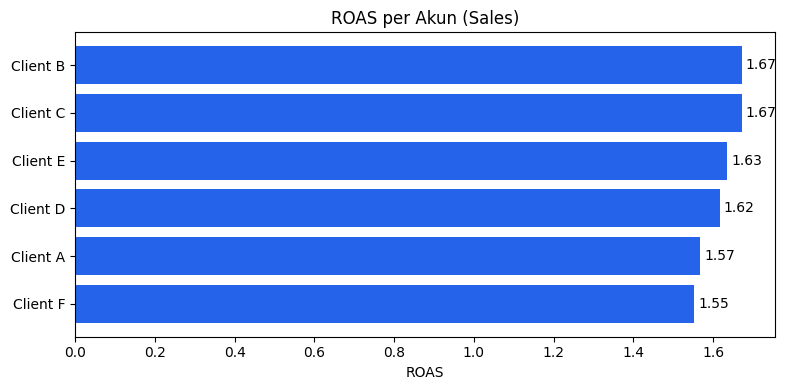

In [ ]:
# Grafik: ROAS per akun
akun_roas = per_akun['ROAS'].sort_values()
plt.figure(figsize=(8, 4))
plt.barh(akun_roas.index, akun_roas.values, color='#2563eb')
plt.title('ROAS per Akun (Sales)')
plt.xlabel('ROAS')
for i, v in enumerate(akun_roas.values):
    plt.text(v + 0.01, i, round(v, 2), va='center')
plt.tight_layout()
plt.show()

**C3 - Industri dengan ROAS tertinggi**

In [ ]:
per_industri = sales.groupby('industry').agg(
    revenue=('purchase_value', 'sum'),
    spend=('amount_spent', 'sum'),
)
per_industri['ROAS'] = per_industri['revenue'] / per_industri['spend']
print(per_industri[['ROAS']].sort_values('ROAS', ascending=False))

              ROAS
industry          
Beauty    1.643435
Fashion   1.619265
FMCG      1.592934


## FUNNEL ANALYSIS (Sales)

Di tahap funnel mana konversi paling banyak bocor?

In [ ]:
# jumlahkan tiap tahap funnel
tahap = sales[['impressions', 'clicks', 'link_clicks',
               'content_views', 'add_to_cart', 'purchase']].sum()

In [ ]:
# hitung persentase lolos tiap tahap
print("impressions -> clicks     :", round(tahap['clicks'] / tahap['impressions'] * 100, 2), "%")
print("clicks -> link_clicks     :", round(tahap['link_clicks'] / tahap['clicks'] * 100, 2), "%")
print("link_clicks -> content    :", round(tahap['content_views'] / tahap['link_clicks'] * 100, 2), "%")
print("content -> add_to_cart    :", round(tahap['add_to_cart'] / tahap['content_views'] * 100, 2), "%")
print("add_to_cart -> purchase   :", round(tahap['purchase'] / tahap['add_to_cart'] * 100, 2), "%")

impressions -> clicks     : 9.88 %
clicks -> link_clicks     : 49.92 %
link_clicks -> content    : 20.39 %
content -> add_to_cart    : 10.08 %
add_to_cart -> purchase   : 90.98 %


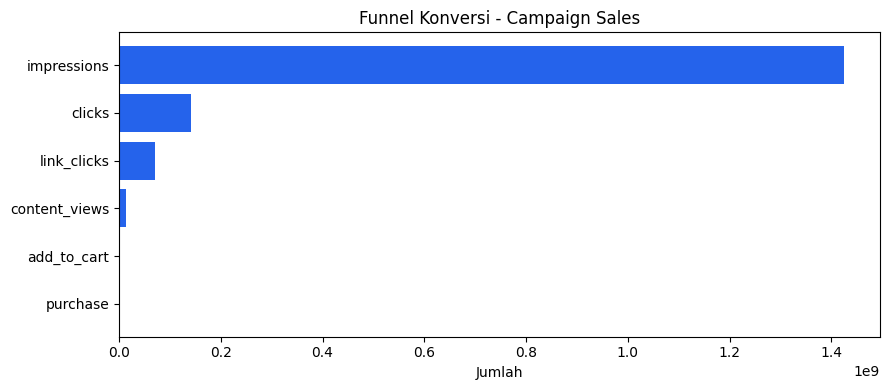

In [ ]:
# --- Grafik: funnel ---
plt.figure(figsize=(9, 4))
plt.barh(tahap.index[::-1], tahap.values[::-1], color='#2563eb')
plt.title('Funnel Konversi - Campaign Sales')
plt.xlabel('Jumlah')
plt.tight_layout()
plt.show()